# Heart Failure Prediction Dataset (EDA)

In this project, we explore a dataset designed to predict heart disease based on clinical patient features. The goal of the analysis is to understand the structure of the data, interpret the features, check data quality, study the relationship between predictors and the target variable, and formulate conclusions that can support future modeling.

1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

2. Load the data

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


3. Initial data overview

In [16]:
df.shape
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


shape shows the size of the dataset, info() shows column types and missing values, and describe(include="all") gives a quick overview of both numerical and categorical variables.

The dataset contains patient records with clinical characteristics. It includes both numerical and categorical variables, which is typical for medical data. At first glance, the dataset is suitable for a binary classification task, where the goal is to predict the presence of heart disease.

Feature description

In [17]:
feature_description = pd.DataFrame({
    "Feature": [
        "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
        "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina",
        "Oldpeak", "ST_Slope", "HeartDisease"
    ],
    "Type": [
        "Numeric", "Categorical", "Categorical", "Numeric", "Numeric",
        "Binary", "Categorical", "Numeric", "Binary",
        "Numeric", "Categorical", "Target"
    ],
    "Meaning": [
        "Age of the patient",
        "Sex of the patient",
        "Type of chest pain",
        "Resting blood pressure",
        "Serum cholesterol",
        "Fasting blood sugar > 120 mg/dl",
        "Resting ECG result",
        "Maximum heart rate achieved",
        "Exercise-induced angina",
        "ST depression induced by exercise relative to rest",
        "Slope of peak exercise ST segment",
        "Presence of heart disease"
    ]
})

feature_description

,Feature,Type,Meaning
0,Age,Numeric,Age of the patient
1,Sex,Categorical,Sex of the patient
2,ChestPainType,Categorical,Type of chest pain
3,RestingBP,Numeric,Resting blood pressure
4,Cholesterol,Numeric,Serum cholesterol
5,FastingBS,Binary,Fasting blood sugar > 120 mg/dl
6,RestingECG,Categorical,Resting ECG result
7,MaxHR,Numeric,Maximum heart rate achieved
8,ExerciseAngina,Binary,Exercise-induced angina
9,Oldpeak,Numeric,ST depression induced by exercise relative to ...


The dataset includes features related to age, sex, ECG results, stress-test measurements, blood pressure, cholesterol, and symptoms during exercise. The most important variables are likely to be ChestPainType, ExerciseAngina, Oldpeak, MaxHR, and ST_Slope, because they are directly connected to cardiovascular function.

## Data quality check

Missing values

In [23]:
df.isnull().sum().sort_values(ascending=False)

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Duplicate rows

In [24]:
df.duplicated().sum()

np.int64(0)

Data types

This helps us verify whether the columns are stored in the expected format. Categorical features often appear as object, while numerical features are stored as integer or float types.

In [21]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


## Target variable analysis

In [25]:
target_counts = df["HeartDisease"].value_counts()
target_pct = df["HeartDisease"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct.round(2)
})
target_summary

,count,percent
HeartDisease,,
1,508,55.34
0,410,44.66


Here we inspect the balance of the classes. This matters because class imbalance can strongly affect model training and evaluation.

**The target variable is binary**: 1 indicates the presence of heart disease, while 0 indicates its absence. If one class is much more frequent than the other, this should be taken into account when choosing evaluation metrics and building the model.

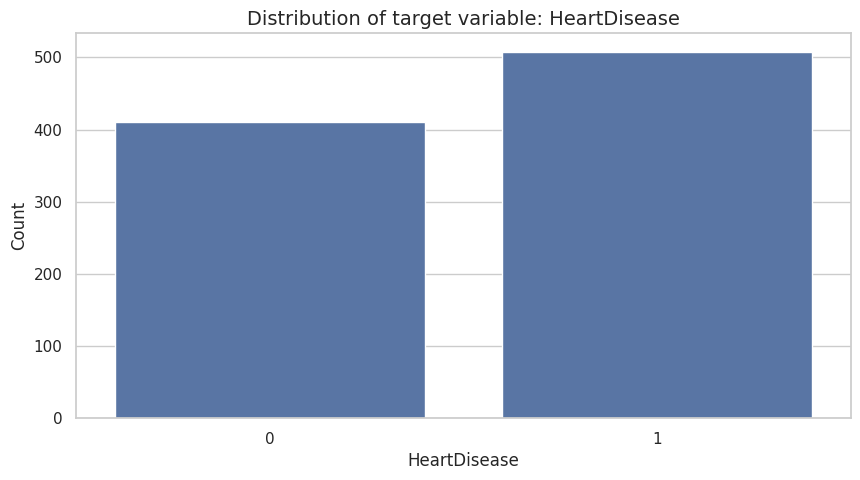

In [26]:
sns.countplot(data=df, x="HeartDisease")
plt.title("Distribution of target variable: HeartDisease")
plt.xlabel("HeartDisease")
plt.ylabel("Count")
plt.show()

The target variable is binary: 1 indicates the presence of heart disease, while 0 indicates its absence. If one class is much more frequent than the other, this should be taken into account when choosing evaluation metrics and building the model.

## Split features by type

In [29]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['Age',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'MaxHR',
  'Oldpeak',
  'HeartDisease'],
 ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

In [30]:
if "HeartDisease" in num_cols:
    num_cols.remove("HeartDisease")

This makes the analysis more convenient: numerical variables can be studied through distributions and outliers, while categorical variables are better explored using counts and proportions.

## Univariate analysis

Numerical features

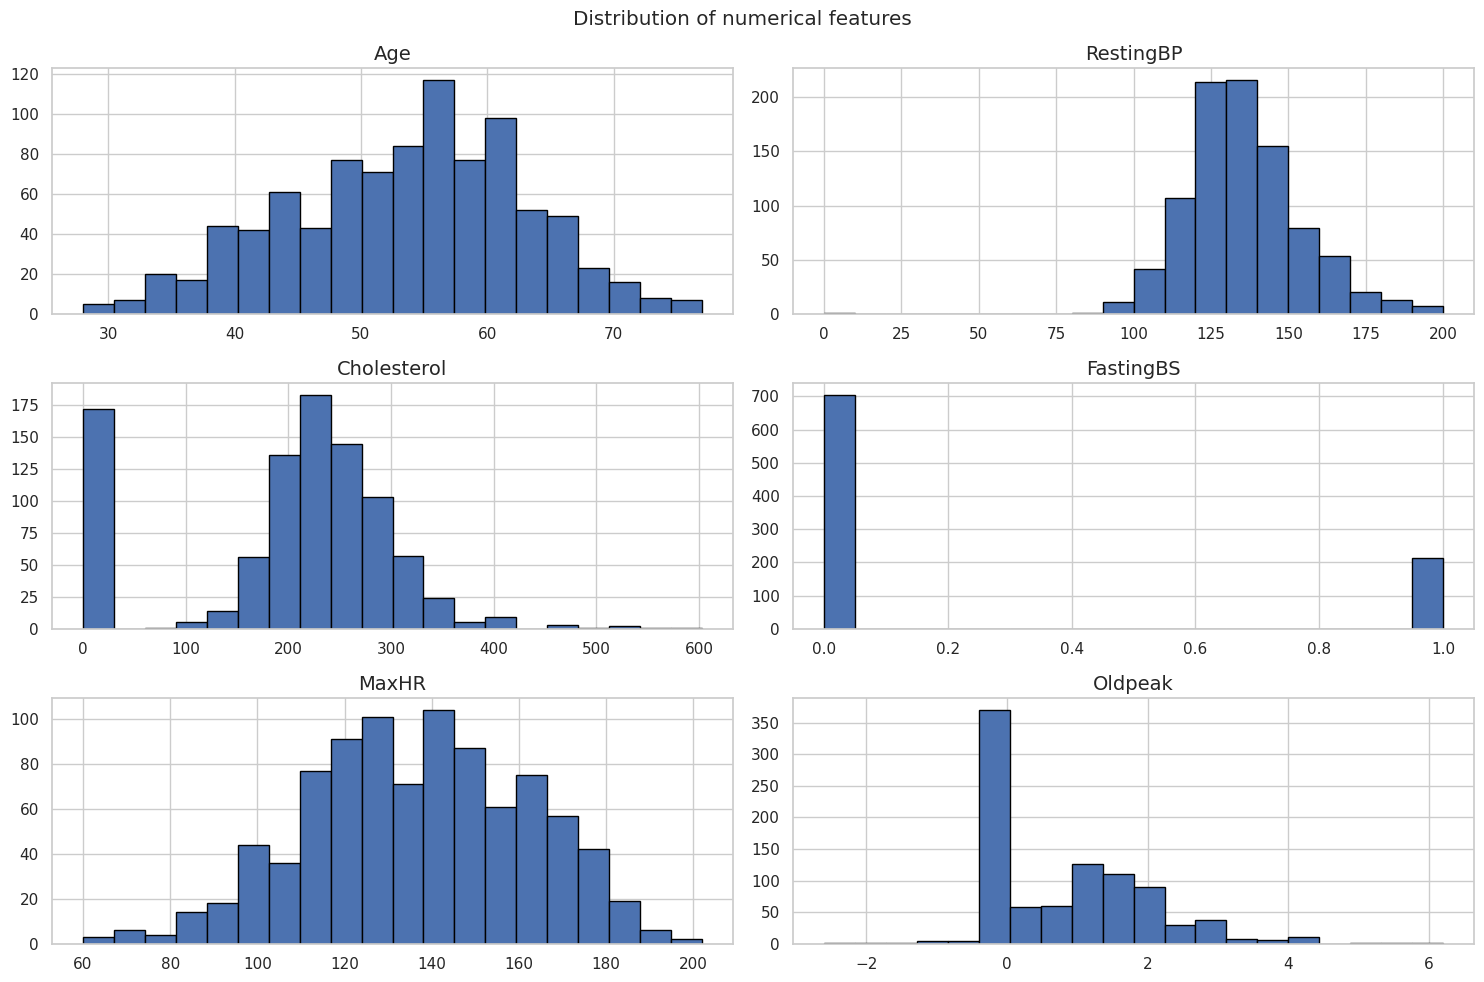

In [31]:
df[num_cols].hist(bins=20, figsize=(15, 10), edgecolor="black")
plt.suptitle("Distribution of numerical features")
plt.tight_layout()
plt.show()

Numerical variables in medical datasets are often not perfectly normally distributed. Therefore, it is important to look not only at averages, but also at the distribution shape, skewness, and potential outliers.

Categorical features

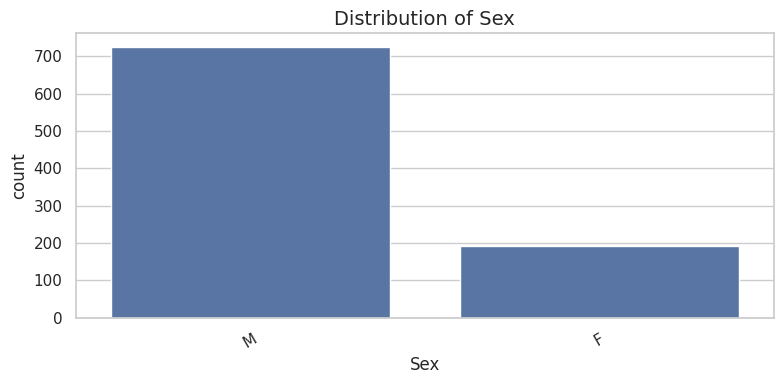

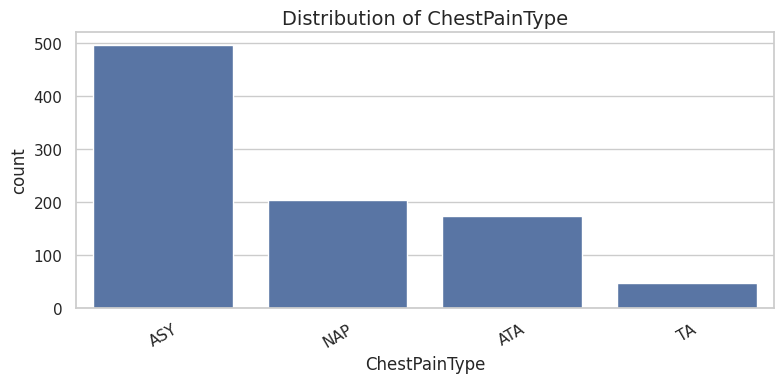

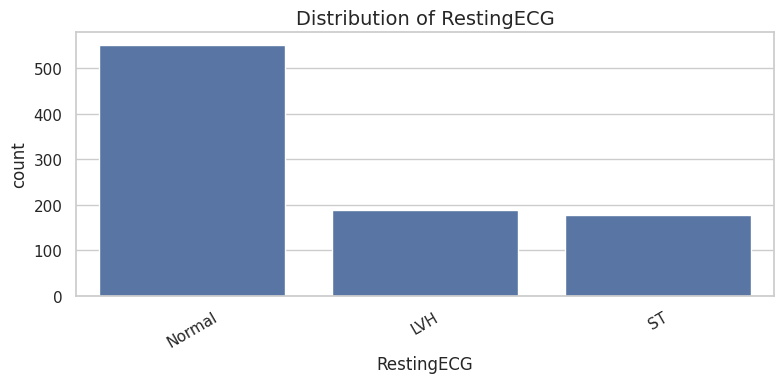

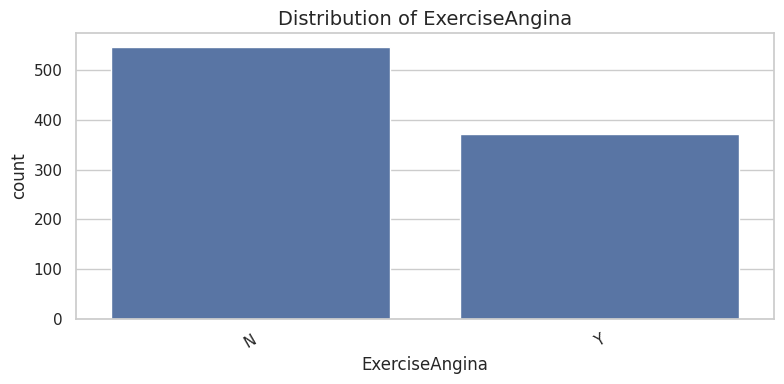

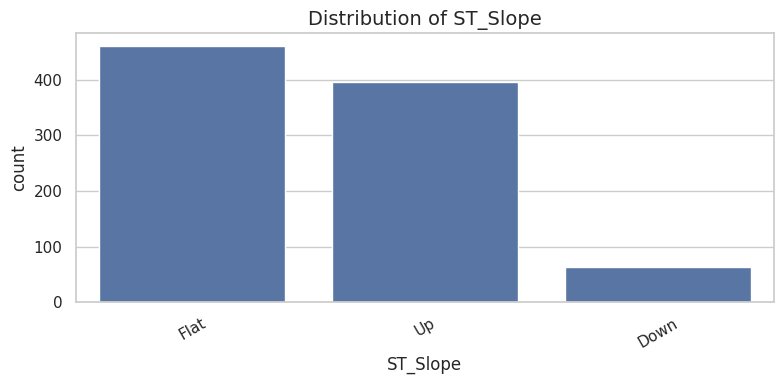

In [32]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

These plots show how the categories are distributed inside each feature. This helps us see whether some classes are rare.

## Outlier analysis

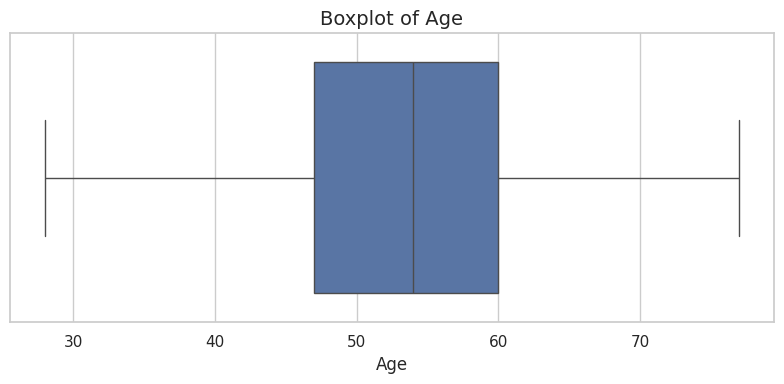

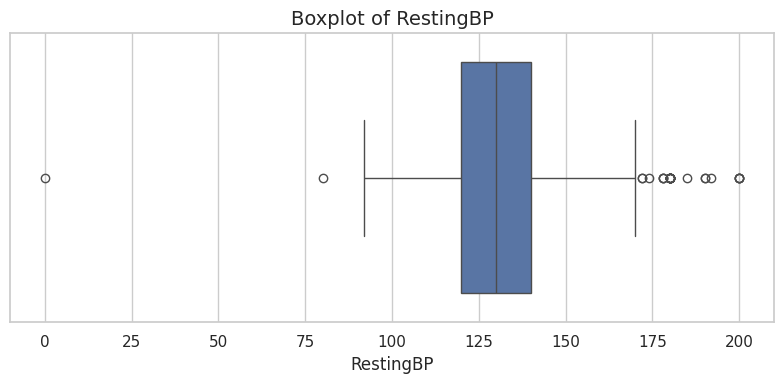

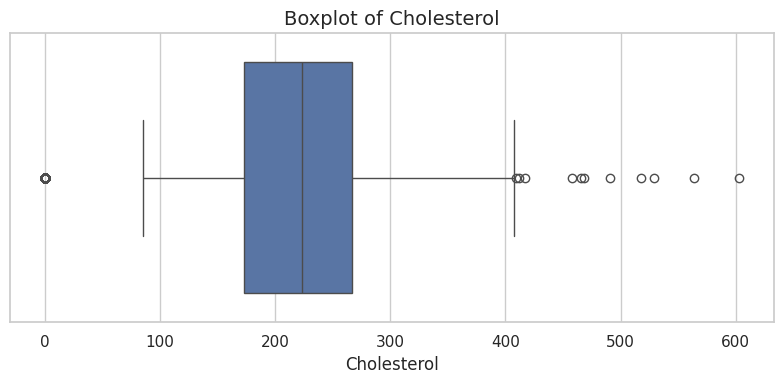

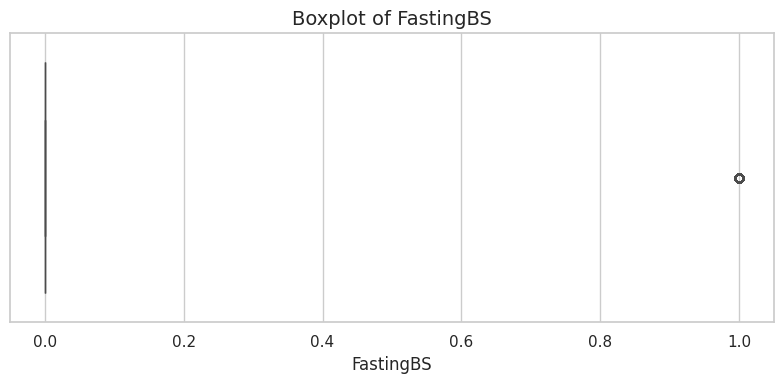

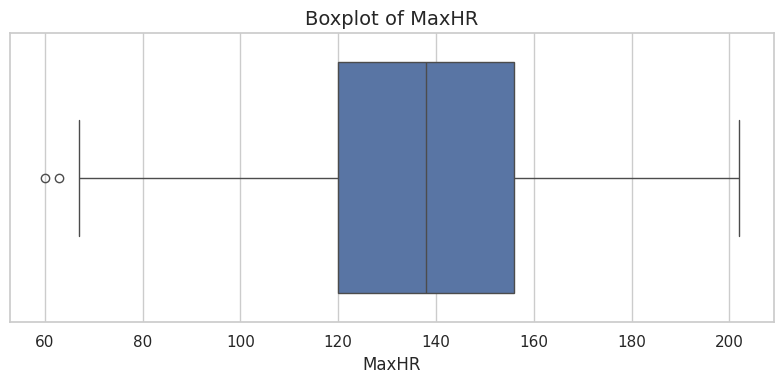

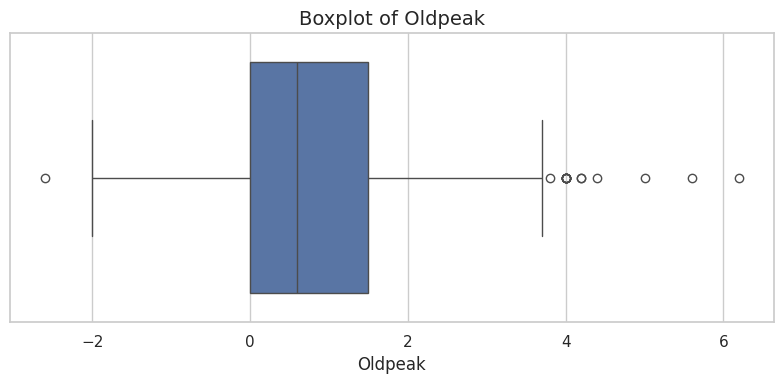

In [33]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

Boxplots are useful for detecting potential outliers. In medical data, this is especially relevant for variables like RestingBP, Cholesterol, and Oldpeak.

Some numerical features may contain values that lie far outside the main distribution. This does not necessarily mean that these values are errors. In medical data, they may reflect rare but real clinical cases.

## Relationship with the target: bivariate analysis

Numerical features vs HeartDisease

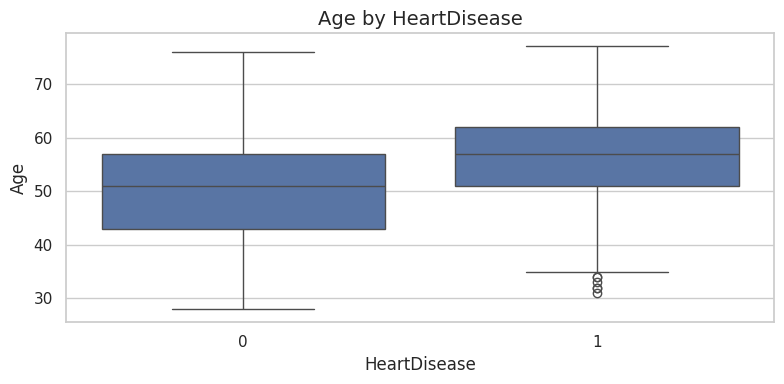

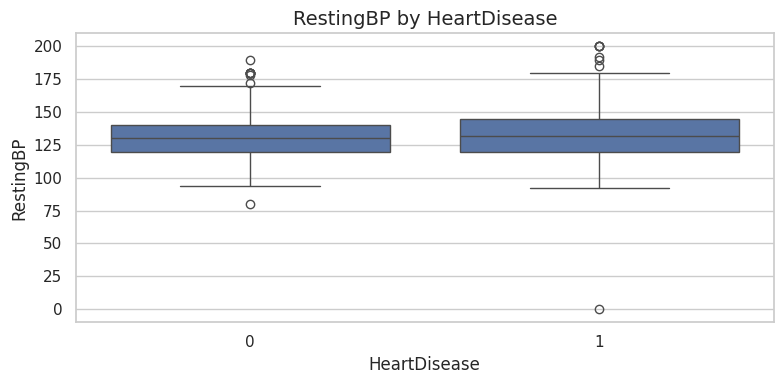

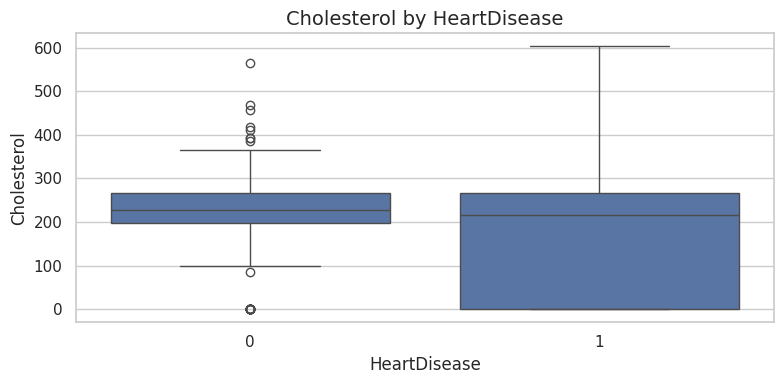

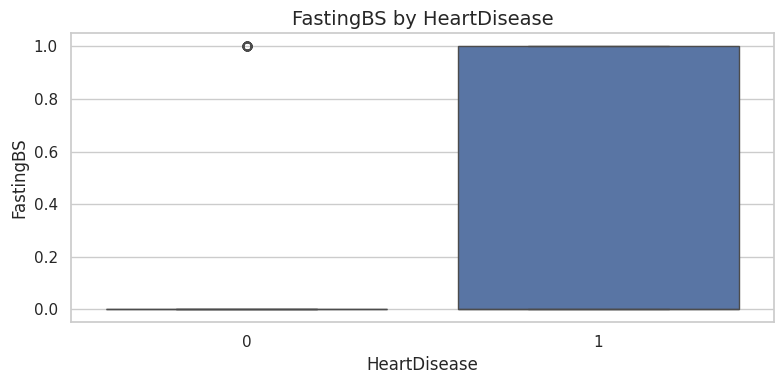

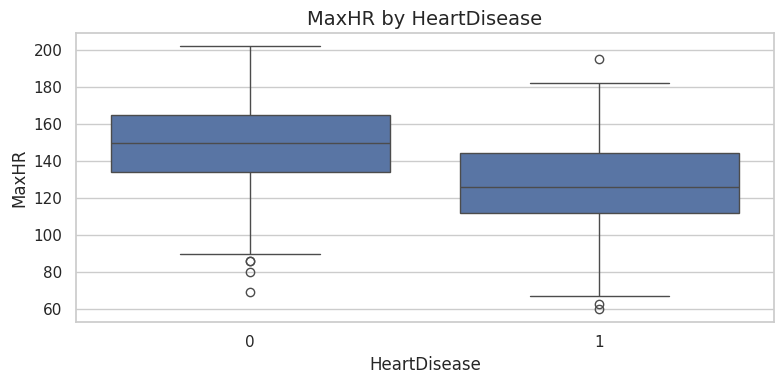

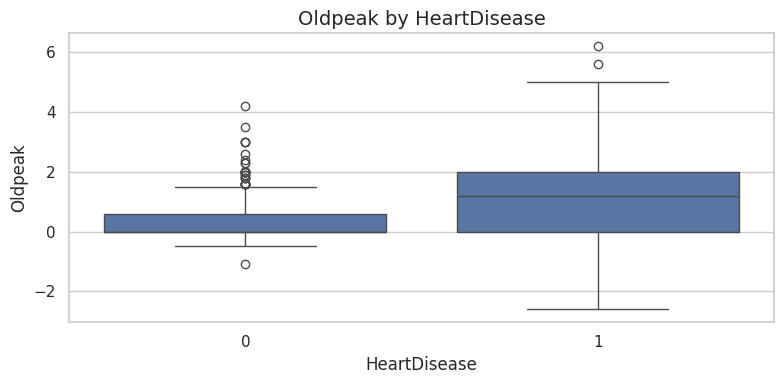

In [35]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="HeartDisease", y=col)
    plt.title(f"{col} by HeartDisease")
    plt.tight_layout()
    plt.show()

This shows whether the distributions of the numerical features differ between patients with and without heart disease.

For Age, we often expect higher values in the HeartDisease = 1 group. For MaxHR, the opposite pattern is often observed: patients with heart disease may achieve lower maximum heart rates. Oldpeak also often shows larger values in the positive class.

Categorical features vs HeartDisease

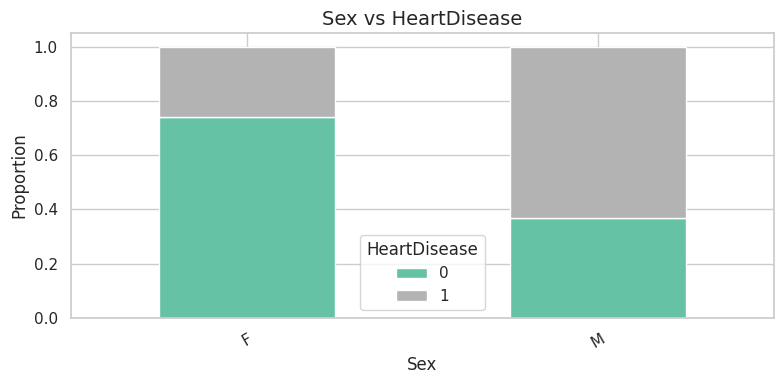

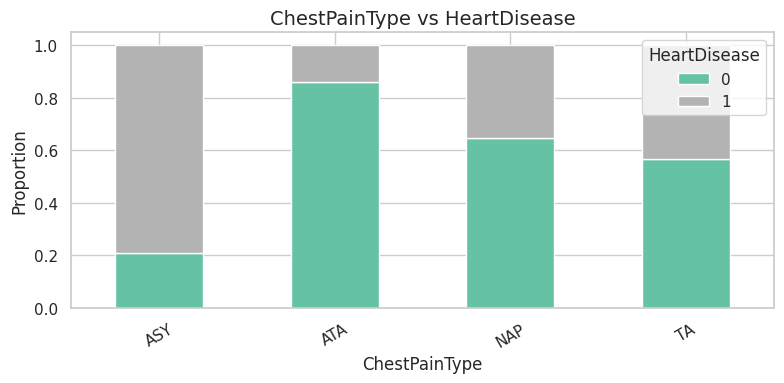

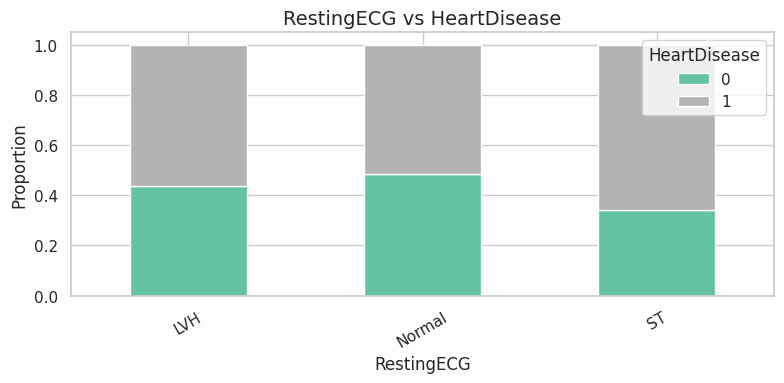

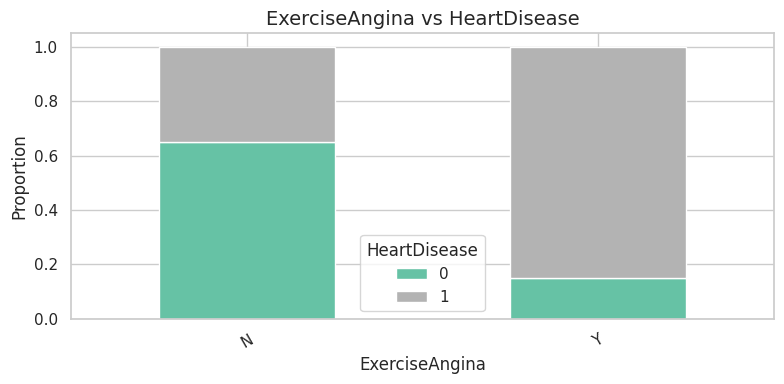

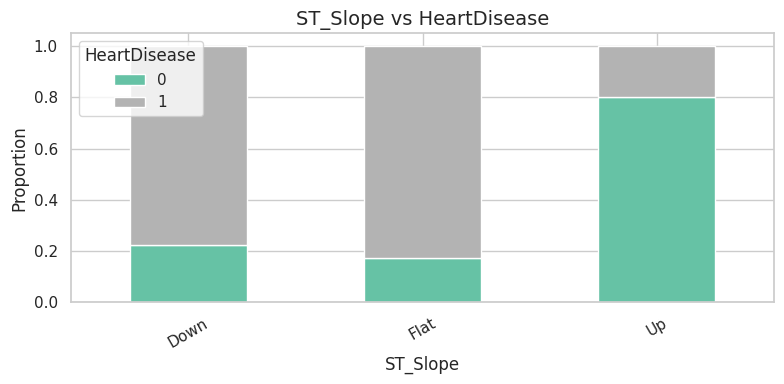

In [36]:
for col in cat_cols:
    pd.crosstab(df[col], df["HeartDisease"], normalize="index").plot(
        kind="bar", stacked=True, figsize=(8, 4), colormap="Set2"
    )
    plt.title(f"{col} vs HeartDisease")
    plt.ylabel("Proportion")
    plt.xticks(rotation=30)
    plt.legend(title="HeartDisease")
    plt.tight_layout()
    plt.show()

Stacked bar plots are convenient for comparing the proportion of target classes inside each category.

The most informative categorical features are often ChestPainType, ExerciseAngina, and ST_Slope. If one category is much more common among patients with heart disease, that feature is likely to be useful for prediction.

Correlation analysis

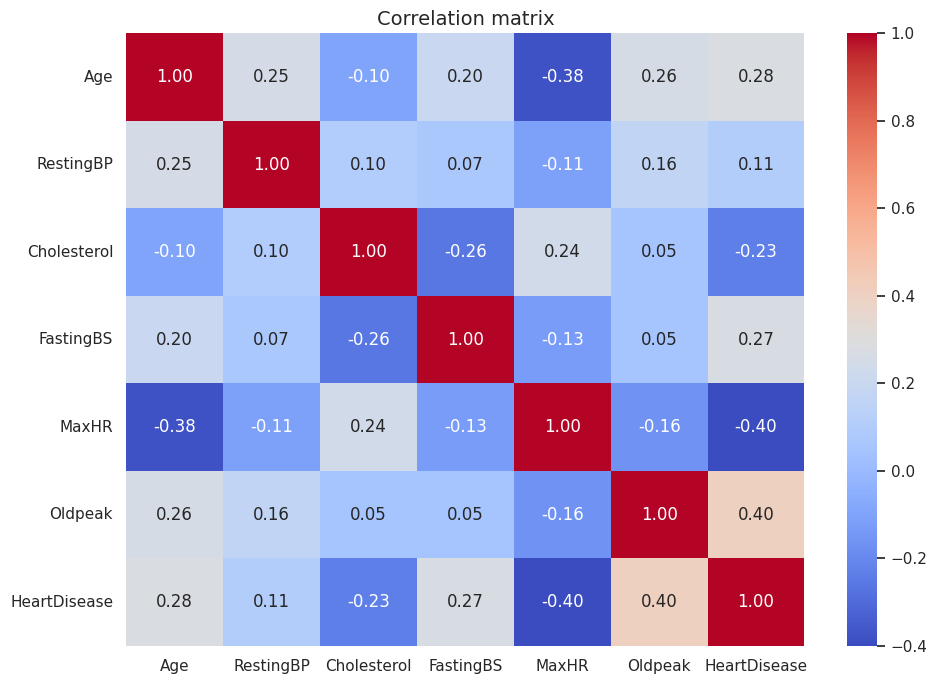

In [37]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols + ["HeartDisease"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

The correlation matrix shows linear relationships between numerical features and the target. However, it does not capture categorical variables and may miss nonlinear effects.

## Multivariate analysis

Age and MaxHR

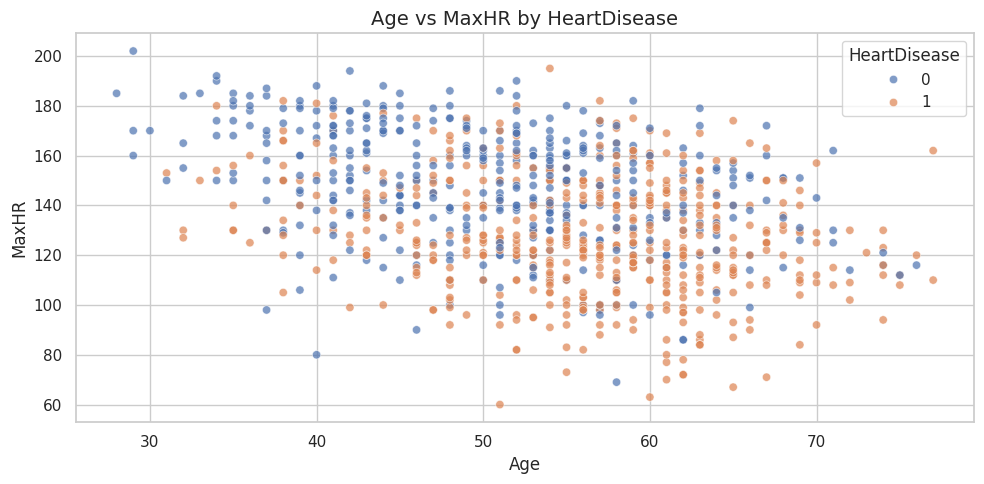

In [38]:
sns.scatterplot(data=df, x="Age", y="MaxHR", hue="HeartDisease", alpha=0.7)
plt.title("Age vs MaxHR by HeartDisease")
plt.tight_layout()
plt.show()

This plot helps us observe how two important features behave together. Patients with heart disease often show lower maximum heart rate values.

Age and Sex

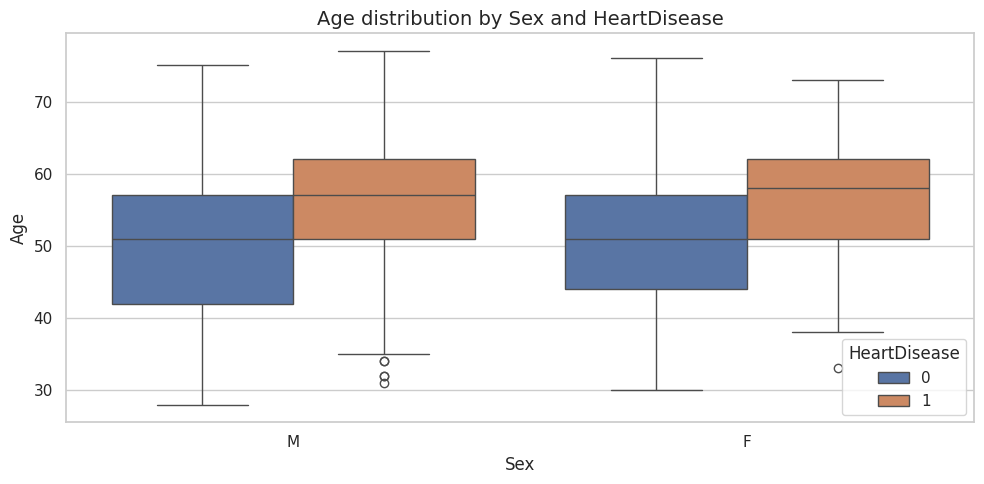

In [39]:
sns.boxplot(data=df, x="Sex", y="Age", hue="HeartDisease")
plt.title("Age distribution by Sex and HeartDisease")
plt.tight_layout()
plt.show()

This graph allows us to see whether the relationship between age and heart disease differs by sex.

ChestPainType and ST_Slope

In [40]:
ct = pd.crosstab([df["ChestPainType"], df["ST_Slope"]], df["HeartDisease"], normalize="index")
ct

HeartDisease                   0         1
ChestPainType ST_Slope                    
ASY           Down      0.086957  0.913043
              Flat      0.091195  0.908805
              Up        0.537879  0.462121
ATA           Down      0.666667  0.333333
              Flat      0.437500  0.562500
              Up        0.963768  0.036232
NAP           Down      0.500000  0.500000
              Flat      0.329545  0.670455
              Up        0.923810  0.076190
TA            Down      0.750000  0.250000
              Flat      0.318182  0.681818
              Up        0.800000  0.200000

Combinations of categorical features can be more informative than each variable separately. For example, a certain chest pain type together with an unfavorable ST slope may indicate a higher risk of heart disease.

## Feature engineering

In [41]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 40, 55, 70, 100],
    labels=["<40", "40-55", "55-70", "70+"]
)

df["HighOldpeak"] = (df["Oldpeak"] > df["Oldpeak"].median()).astype(int)
df["LowMaxHR"] = (df["MaxHR"] < df["MaxHR"].median()).astype(int)

df[["Age", "AgeGroup", "Oldpeak", "HighOldpeak", "MaxHR", "LowMaxHR"]].head()

,Age,AgeGroup,Oldpeak,HighOldpeak,MaxHR,LowMaxHR
0,40,<40,0.0,0,172,0
1,49,40-55,1.0,1,156,0
2,37,<40,0.0,0,98,1
3,48,40-55,1.5,1,108,1
4,54,40-55,0.0,0,122,1


Additional features may improve a model if the original variables have nonlinear effects. For example, age can be grouped into intervals, and Oldpeak and MaxHR can be transformed into simple high-risk / low-risk indicators.

## Preparing categorical features for modeling

In [42]:
df_model = df.copy()

df_model = pd.get_dummies(
    df_model,
    columns=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "AgeGroup"],
    drop_first=True
)

df_model.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,HighOldpeak,LowMaxHR,Sex_M,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,AgeGroup_40-55,AgeGroup_55-70,AgeGroup_70+
0,40,140,289,0,172,0.0,0,0,0,True,...,False,False,True,False,False,False,True,False,False,False
1,49,160,180,0,156,1.0,1,1,0,False,...,True,False,True,False,False,True,False,True,False,False
2,37,130,283,0,98,0.0,0,0,1,True,...,False,False,False,True,False,False,True,False,False,False
3,48,138,214,0,108,1.5,1,1,1,False,...,False,False,True,False,True,True,False,True,False,False
4,54,150,195,0,122,0.0,0,0,1,True,...,True,False,True,False,False,False,True,True,False,False


Encoding categorical variables is necessary for most machine learning methods. In this dataset, one-hot encoding is especially appropriate because the categories are nominal rather than ordered.

## *Conclusion 1*

The dataset contains clinical patient information and is suitable for a binary classification task: predicting the presence of heart disease based on multiple risk factors.

## *Conclusion 2*

The data includes both numerical and categorical variables, so a complete analysis requires different methods: histograms, boxplots, contingency tables, and correlation analysis.

## *Conclusion 3*

The most informative features are likely ChestPainType, ExerciseAngina, ST_Slope, Oldpeak, Age, and MaxHR. These variables reflect symptoms, stress-test results, and general cardiovascular status.

## *Conclusion 4*

Data quality checking should start with missing values, duplicates, and outliers. Based on the available dataset description, the data appears complete, but numerical features still need careful inspection for unusual values.

## *Conclusion 5*

The relationship with the target is multivariate rather than driven by a single variable. This means that combinations of features are likely more useful than isolated predictors.

## *Conclusion 6*
Before modeling, categorical variables should be encoded with one-hot encoding, and feature engineering may help by creating age groups or simple risk indicators.

## *Conclusion 7*

The main practical message of this dataset is that heart disease risk depends on a combination of factors rather than one isolated measurement. Therefore, both EDA and future modeling should focus on interactions between variables.